# Trajectory-Based Clustering

### How do gender outcomes evolve across the major dimensions of development (Health, Education, Economy, Governance, Legal Rights, Labor, Demographics)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.1)
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/traj_Clu")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/traj_Clu')

In [5]:
t_df = pd.read_csv("data/ml_df_category_features.csv")

In [6]:
t_df.head()

,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,cat_LegalAutonomy_dip,cat_WBL_dip,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,0,0,9.831378,42.698491,2.168538,54.315497,7.623581,17.664367,11.644944,12.963328
1,Bahrain,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,GCC,LegalAutonomy,...,0,0,17.300106,148.348564,4.082102,115.166647,14.764488,17.646290,111.650485,70.443579
2,"Egypt, Arab Rep.",2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,LegalAutonomy,...,1,5,9.782721,48.467036,1.966604,95.458049,11.399639,14.223896,4.259982,51.652584
3,"Iran, Islamic Rep.",2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,Other,LegalAutonomy,...,0,0,10.156327,51.399762,2.463409,30.083647,11.904242,8.637242,0.000000,7.887084
4,Iraq,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,Other,LegalAutonomy,...,0,0,16.134175,97.477909,338.809971,76.112801,11.744987,19.091896,24.077171,50.603937


In [7]:
# Keep a copy of country & region for later interpretation
id_cols = ["country_name"]
if "region" in t_df.columns:
    id_cols.append("region")

# All category-level features start with "cat_"
traj_cols = [c for c in t_df.columns if c.startswith("cat_")]

print("ID columns:", id_cols)
print("Trajectory features (n={}):".format(len(traj_cols)))
traj_cols[:7]


ID columns: ['country_name', 'region']
Trajectory features (n=56):


['cat_Demographics_trend_slope',
 'cat_Economy_trend_slope',
 'cat_Education_trend_slope',
 'cat_Governance_trend_slope',
 'cat_Health_trend_slope',
 'cat_Labor_trend_slope',
 'cat_LegalAutonomy_trend_slope']

In [8]:
t_df[traj_cols].isna().mean().sort_values(ascending=False).head(10)


cat_LegalAutonomy_cagr              1.000000
cat_LegalAutonomy_rolling_std_5y    1.000000
cat_Governance_momentum             0.111111
cat_Governance_cagr                 0.111111
cat_Education_dip                   0.000000
cat_Demographics_spike              0.000000
cat_Economy_spike                   0.000000
cat_Education_spike                 0.000000
cat_Governance_spike                0.000000
cat_Health_spike                    0.000000
dtype: float64

In [10]:
null_ratio = t_df[traj_cols].isna().mean()

drop_cols = null_ratio[null_ratio == 1.0].index.tolist()

print("Dropping fully-null columns:", drop_cols)

traj_cols = [c for c in traj_cols if c not in drop_cols]


Dropping fully-null columns: []


### Region-Wise Median Imputation

In [11]:
id_cols = ["country_name", "region"]

traj_df = t_df[id_cols + traj_cols].copy()



In [12]:
def region_median_impute(df, feature_cols, region_col="region"):
    """
    Impute missing trajectory features using region-specific medians.
    Falls back to global median if a region has all missing.
    """
    df = df.copy()
    
    for col in feature_cols:
        # If a region has valid non-NaN values, use its median
        df[col] = df.groupby(region_col)[col].transform(
            lambda g: g.fillna(g.median())
        )

        # Fallback: if still NaN, fill with global median
        df[col] = df[col].fillna(df[col].median())

    return df


In [13]:
traj_df_imputed = region_median_impute(
    df=traj_df,
    feature_cols=traj_cols,
    region_col="region"
)


In [14]:
traj_df_imputed[traj_cols].isna().sum()


cat_Demographics_trend_slope        0
cat_Economy_trend_slope             0
cat_Education_trend_slope           0
cat_Governance_trend_slope          0
cat_Health_trend_slope              0
cat_Labor_trend_slope               0
cat_LegalAutonomy_trend_slope       0
cat_WBL_trend_slope                 0
cat_Demographics_cagr               0
cat_Economy_cagr                    0
cat_Education_cagr                  0
cat_Governance_cagr                 0
cat_Health_cagr                     0
cat_Labor_cagr                      0
cat_WBL_cagr                        0
cat_Demographics_momentum           0
cat_Economy_momentum                0
cat_Education_momentum              0
cat_Governance_momentum             0
cat_Health_momentum                 0
cat_Labor_momentum                  0
cat_LegalAutonomy_momentum          0
cat_WBL_momentum                    0
cat_Demographics_rolling_std_5y     0
cat_Economy_rolling_std_5y          0
cat_Education_rolling_std_5y        0
cat_Governan

### Scale Features


In [15]:

# Check for inf or -inf
inf_mask = traj_df_imputed[traj_cols].isin([np.inf, -np.inf])
inf_mask.sum().sum()


42

In [16]:
traj_df_imputed.loc[
    np.isinf(traj_df_imputed[traj_cols]).any(axis=1),
    ["country_name"] + traj_cols
]


,country_name,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,...,cat_LegalAutonomy_dip,cat_WBL_dip,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation
0,Algeria,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.732880,0.662845,...,0,0,9.831378,42.698491,2.168538,54.315497,7.623581,17.664367,11.644944,12.963328
1,Bahrain,14026.204516,336.595084,-0.001317,0.374724,-0.078164,0.046087,0.013106,1.498370,0.337694,...,0,0,17.300106,148.348564,4.082102,115.166647,14.764488,17.646290,111.650485,70.443579
2,"Egypt, Arab Rep.",614475.987699,64.370153,0.002327,0.690524,-0.354701,-0.154470,0.000714,0.706250,0.350202,...,1,5,9.782721,48.467036,1.966604,95.458049,11.399639,14.223896,4.259982,51.652584
4,Iraq,308642.321996,108.543046,26558.151664,0.102132,-0.723706,0.066903,0.003975,0.720652,-0.024813,...,0,0,16.134175,97.477909,338.809971,76.112801,11.744987,19.091896,24.077171,50.603937
5,Jordan,98412.256675,67.823151,-0.000739,0.277076,-0.294004,0.047310,0.006149,1.033152,0.502753,...,0,0,15.192267,57.121038,0.683590,191.357382,11.859755,11.810674,131.063226,105.172341
6,Kuwait,45308.016349,158.743364,0.001546,0.262534,0.051432,0.091653,0.004348,0.404891,0.627484,...,0,0,21.740955,32.945305,2.462400,146.445659,43.087508,42.026407,14.388862,52.999962
8,Libya,26841.249916,11.899386,28321.918329,0.408272,0.042419,0.113092,0.004348,0.684783,0.824404,...,0,0,9.828917,49.054496,270.283668,84.354873,9.474382,7.323633,9.592574,23.631066
9,Morocco,137160.512955,45.323362,0.006593,0.483078,-2.042651,-0.405002,0.004969,1.133696,-0.164858,...,8,24,7.709234,46.910727,5.669862,47.338527,15.157725,12.196046,9.136644,19.628163
10,Oman,45317.024553,210.016571,-0.002214,0.018818,0.062596,0.060398,0.002671,0.277446,-0.389506,...,0,3,18.066465,81.871856,2.897090,45.077182,28.483957,29.787090,108.594788,89.715860
11,Qatar,35709.367466,971.638077,-0.004045,0.186848,-0.073965,0.102988,0.001211,0.115489,0.426520,...,0,0,31.618142,68.590140,5.012761,117.617866,19.087814,41.346392,36.745641,18.097346


In [17]:
# Identify infinite values
inf_cols = traj_df_imputed[traj_cols].isin([np.inf, -np.inf]).any()
inf_cols[inf_cols]


cat_Governance_momentum       True
cat_LegalAutonomy_momentum    True
cat_WBL_momentum              True
dtype: bool

In [18]:
traj_df_imputed[traj_cols].max().sort_values(ascending=False).head(20)


cat_Demographics_rolling_std_5y     902784.601268
cat_Demographics_trend_slope        614475.987699
cat_Education_rolling_std_5y         68838.249487
cat_Education_trend_slope            28321.918329
cat_Governance_rolling_std_5y         6405.228918
cat_Economy_rolling_std_5y            5909.024448
cat_Governance_trend_slope            2632.619395
cat_Economy_trend_slope                971.638077
cat_Education_coef_variation           338.809971
cat_Governance_coef_variation          191.357382
cat_LegalAutonomy_coef_variation       157.259073
cat_Economy_coef_variation             148.348564
cat_WBL_coef_variation                 120.557208
cat_Health_coef_variation               43.087508
cat_Labor_coef_variation                42.325549
cat_Demographics_coef_variation         31.618142
cat_Governance_cagr                     28.199380
cat_WBL_dip                             24.000000
cat_WBL_spike                           24.000000
cat_LegalAutonomy_spike                 18.000000


### Replace infinities with NaN

In [19]:
traj_clean = traj_df_imputed.copy()
traj_clean[traj_cols] = traj_clean[traj_cols].replace([np.inf, -np.inf], np.nan)


#### Winsorize (clip) extreme values using percentiles

In [20]:
for col in traj_cols:
    lower = traj_clean[col].quantile(0.01)  # 1st percentile
    upper = traj_clean[col].quantile(0.99)  # 99th percentile
    traj_clean[col] = traj_clean[col].clip(lower, upper)


In [21]:
traj_clean[traj_cols] = traj_clean[traj_cols].fillna(traj_clean[traj_cols].mean())


In [22]:

scaler = StandardScaler()

traj_scaled = scaler.fit_transform(traj_clean[traj_cols])

tr_df = pd.DataFrame(
    traj_scaled,
    columns=traj_cols,
    index=traj_df_imputed["country_name"]
)

tr_df.head()


,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,cat_Economy_cagr,...,cat_LegalAutonomy_dip,cat_WBL_dip,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.549136,-0.473852,-0.350839,-0.242434,0.224166,-0.921896,0.071014,-0.046670,1.132363,1.547746,...,-0.277556,-0.355247,-0.984961,-0.771285,-0.461836,-0.725564,-0.991195,-0.349694,-0.598305,-0.939696
Bahrain,-0.882325,0.760456,-0.350839,-0.242429,0.562547,0.385428,1.146376,1.179822,0.406997,-0.226594,...,-0.277556,-0.355247,0.315590,2.604167,-0.442636,0.572713,-0.173154,-0.351334,1.184993,0.728257
"Egypt, Arab Rep.",2.822389,-0.456292,-0.350839,-0.241799,0.044399,-0.718898,-0.703062,-0.089338,0.434902,-0.798706,...,0.362138,0.683825,-0.993434,-0.580586,-0.463862,0.152224,-0.576052,-0.661778,-0.729994,0.182982
"Iran, Islamic Rep.",1.395218,-0.504950,-0.350839,-0.243086,0.503907,-0.839522,-0.809671,-0.769852,0.757223,1.852991,...,-0.277556,-0.355247,-0.928377,-0.483635,-0.458877,-1.242557,-0.515632,-1.168541,-0.805958,-1.086998
Iraq,1.071439,-0.258855,2.711630,-0.242974,-0.647004,0.500046,-0.216368,-0.066263,-0.401704,-0.740789,...,-0.277556,-0.355247,0.112563,1.039634,2.798915,-0.260512,-0.534701,-0.220204,-0.376614,0.152553


### PCA on trajectory features (for structure + plots)

In [23]:
traj_pca = PCA()
X_traj_pca = traj_pca.fit_transform(tr_df.values)


traj_var_ratio = traj_pca.explained_variance_ratio_
traj_cumvar = traj_var_ratio.cumsum()

tr_pca = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(traj_var_ratio))],
    "Variance": traj_var_ratio,
    "Cumulative": traj_cumvar
}).head(10)


In [24]:
tr_pca.head()

,PC,Variance,Cumulative
0,PC1,0.217664,0.217664
1,PC2,0.132121,0.349784
2,PC3,0.106948,0.456732
3,PC4,0.095932,0.552664
4,PC5,0.079586,0.632251


### Scree plot for trajectory PCA

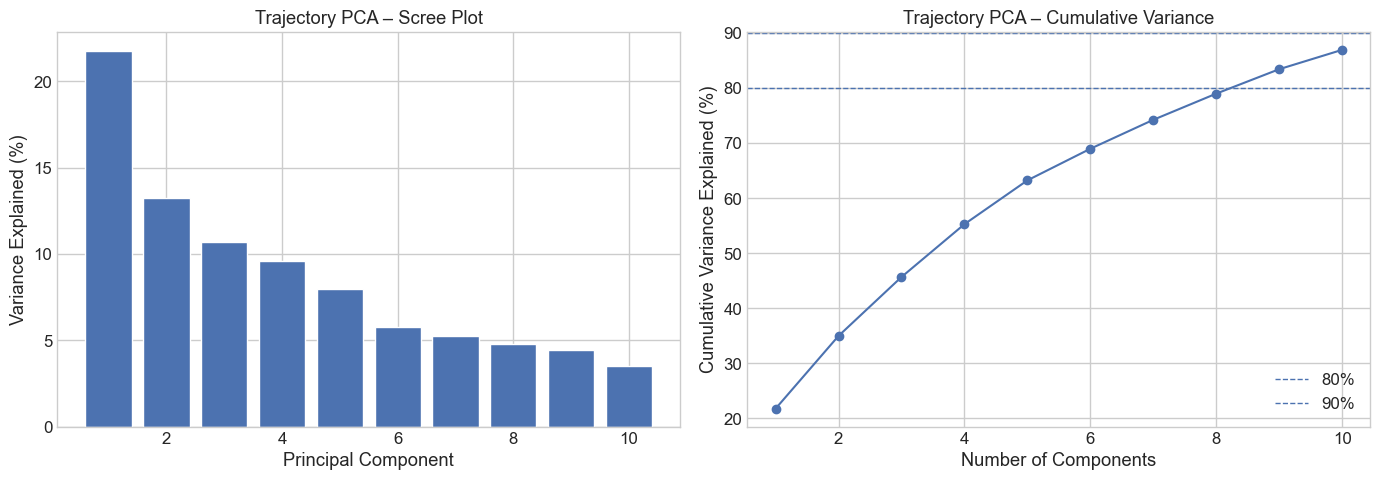

In [25]:
def plot_traj_scree(var_ratio, cumvar, n_show=10):
    pcs = np.arange(1, n_show + 1)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Bar: individual variance
    ax[0].bar(pcs, var_ratio[:n_show] * 100)
    ax[0].set_xlabel("Principal Component")
    ax[0].set_ylabel("Variance Explained (%)")
    ax[0].set_title("Trajectory PCA – Scree Plot")

    # Line: cumulative variance
    ax[1].plot(pcs, cumvar[:n_show] * 100, marker="o")
    ax[1].axhline(80, ls="--", lw=1, label="80%")
    ax[1].axhline(90, ls="--", lw=1, label="90%")
    ax[1].set_xlabel("Number of Components")
    ax[1].set_ylabel("Cumulative Variance Explained (%)")
    ax[1].set_title("Trajectory PCA – Cumulative Variance")
    ax[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "traj_pca_scree.png", dpi=300)
    plt.show()

plot_traj_scree(traj_var_ratio, traj_cumvar, n_show=min(10, tr_df.shape[1]))

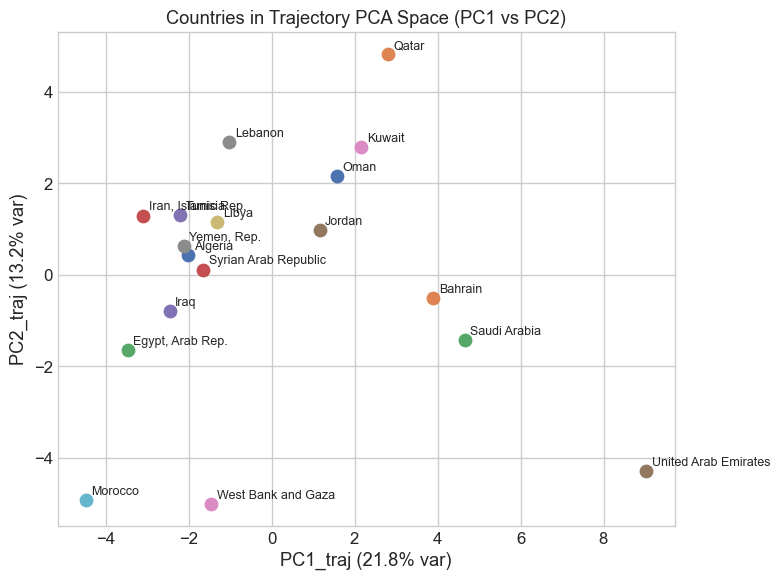

In [26]:
# Build a small PCA summary DF
traj_pca_df = pd.DataFrame(
    X_traj_pca[:, :3],  # first 3 PCs
    index=tr_df.index,
    columns=["PC1_traj", "PC2_traj", "PC3_traj"]
)

country_region = (
    traj_clean[["country_name", "region"]]
    .drop_duplicates()
    .set_index("country_name")["region"]
)

traj_pca_df["region"] = traj_pca_df.index.map(country_region)


fig, ax = plt.subplots(figsize=(8, 6))

for country in traj_pca_df.index:
    ax.scatter(
        traj_pca_df.loc[country, "PC1_traj"],
        traj_pca_df.loc[country, "PC2_traj"],
        s=80
    )
    ax.annotate(
        country,
        (traj_pca_df.loc[country, "PC1_traj"], traj_pca_df.loc[country, "PC2_traj"]),
        fontsize=9,
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.set_xlabel(f"PC1_traj ({traj_var_ratio[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2_traj ({traj_var_ratio[1]*100:.1f}% var)")
ax.set_title("Countries in Trajectory PCA Space (PC1 vs PC2)")

plt.savefig(OUTPUT_DIR / "traj_pca_scatter.png", dpi=300)

plt.tight_layout()
plt.show()


### Extract & interpret PCA loadings

In [27]:
# ==== Cell 12: Inspect PCA loadings to interpret PCs ========================

# components_: shape (n_components, n_features)
loadings = pd.DataFrame(
    traj_pca.components_.T,
    index=traj_cols,
    columns=[f"PC{i+1}" for i in range(len(traj_var_ratio))]
)

# absolute contributions for the first 3 PCs
top_n = 10
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop contributors to {pc}:")
    print(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(top_n)
    )




Top contributors to PC1:
cat_WBL_spike                       0.267271
cat_LegalAutonomy_spike             0.257448
cat_LegalAutonomy_coef_variation    0.244018
cat_LegalAutonomy_trend_slope       0.235015
cat_Labor_coef_variation            0.214828
cat_Demographics_coef_variation     0.212667
cat_WBL_coef_variation              0.212633
cat_Education_cagr                  0.204222
cat_Labor_trend_slope               0.197629
cat_Economy_trend_slope             0.194646
Name: PC1, dtype: float64

Top contributors to PC2:
cat_Governance_spike        0.267369
cat_Governance_cagr         0.237491
cat_WBL_rolling_std_5y      0.234931
cat_Health_trend_slope      0.233722
cat_Labor_cagr              0.229290
cat_Labor_momentum          0.225222
cat_Demographics_cagr       0.206986
cat_WBL_trend_slope         0.191188
cat_Labor_dip               0.187400
cat_Labor_rolling_std_5y    0.184883
Name: PC2, dtype: float64

Top contributors to PC3:
cat_Governance_trend_slope       0.338290
cat_Gove

### Add Category-Level Summary Statistics

In [56]:
# -----------------------------
# CATEGORY-LEVEL SUMMARY STATS
# -----------------------------

summary_df = pd.DataFrame()
summary_df["country_name"] = traj_clean["country_name"].values
summary_df["region"] = traj_clean["region"].values

# Identify subgroups by category-type in the feature names
trend_cols = [c for c in traj_cols if c.endswith("trend_slope")]
cagr_cols = [c for c in traj_cols if c.endswith("cagr")]
momentum_cols = [c for c in traj_cols if c.endswith("momentum")]
vol_cols = [c for c in traj_cols if c.endswith("rolling_std_5y")]

# 1. Improving and declining categories
summary_df["improving_categories"] = (traj_clean[trend_cols] > 0).sum(axis=1)
summary_df["declining_categories"] = (traj_clean[trend_cols] < 0).sum(axis=1)

# 2. Average measures
summary_df["avg_trend_slope"] = traj_clean[trend_cols].mean(axis=1)
summary_df["avg_cagr"] = traj_clean[cagr_cols].mean(axis=1)
summary_df["avg_momentum"] = traj_clean[momentum_cols].mean(axis=1)
summary_df["avg_volatility"] = traj_clean[vol_cols].mean(axis=1)

# 3. Reform intensity score (optional)
summary_df["reform_intensity"] = (
    summary_df["improving_categories"] 
    - summary_df["declining_categories"]
)

# Sort countries by improvement
summary_df = summary_df.sort_values("avg_trend_slope", ascending=False)

summary_df.reset_index(drop=True, inplace=True)

summary_df.head(15)
summary_df.to_csv(OUTPUT_DIR / "2traj_category_summary_stats.csv", index=False)


### Perform cross-model comparison

In [49]:
ml_df = pd.read_csv("data/clustering_1.csv")

In [50]:
structural_cluster_df = ml_df[["country_name", "Cluster", "Cluster_Name"]].drop_duplicates()
structural_cluster_df.head()

,country_name,Cluster,Cluster_Name
0,Algeria,3,North African Reformers
1,Bahrain,1,High-Income Empowerers
2,"Egypt, Arab Rep.",2,Fragile States
3,"Iran, Islamic Rep.",2,Fragile States
4,Iraq,2,Fragile States


In [48]:
merged = traj_pca_df.reset_index().merge(
    structural_cluster_df,
    on="country_name",
    how="left"
)

merged.head()

,country_name,PC1_traj,PC2_traj,PC3_traj,region,traj_cluster,Cluster,Cluster_Name
0,Algeria,-2.009522,0.424644,-0.635280,NaN,1,3,North African Reformers
1,Bahrain,3.900537,-0.513983,-0.772148,NaN,5,1,High-Income Empowerers
2,"Egypt, Arab Rep.",-3.473431,-1.642355,-1.407805,NaN,1,2,Fragile States
3,"Iran, Islamic Rep.",-3.100714,1.295938,0.349195,NaN,1,2,Fragile States
4,Iraq,-2.462522,-0.787292,-1.192613,NaN,1,2,Fragile States


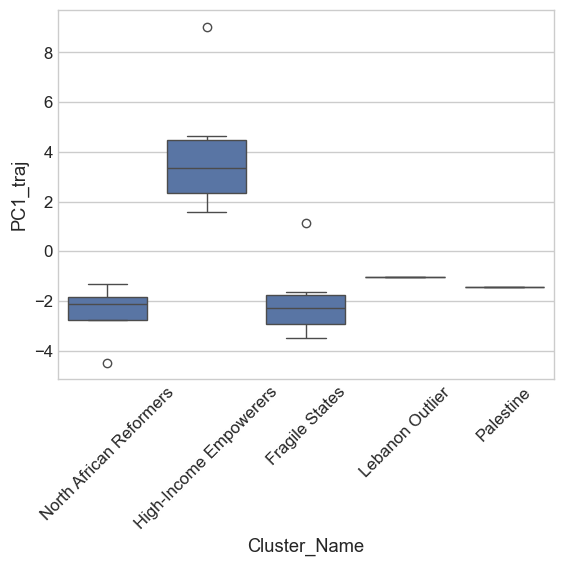

In [49]:
sns.boxplot(
    data=merged,
    x="Cluster_Name",
    y="PC1_traj"
)
plt.xticks(rotation=45)
plt.show()



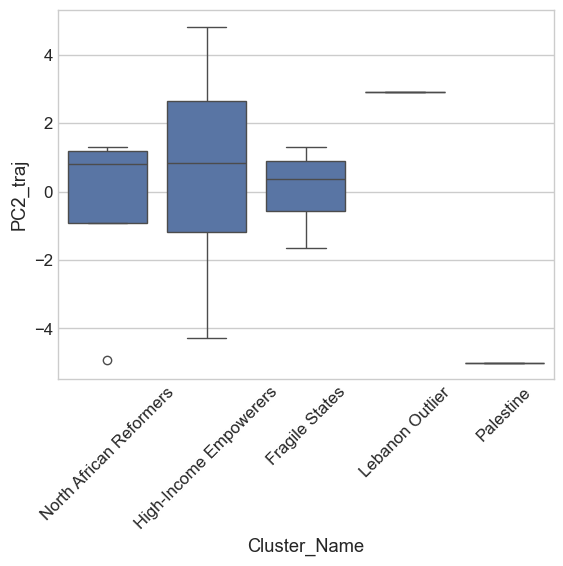

In [50]:
sns.boxplot(
    data=merged,
    x="Cluster_Name",
    y="PC2_traj"
)
plt.xticks(rotation=45)
plt.show()


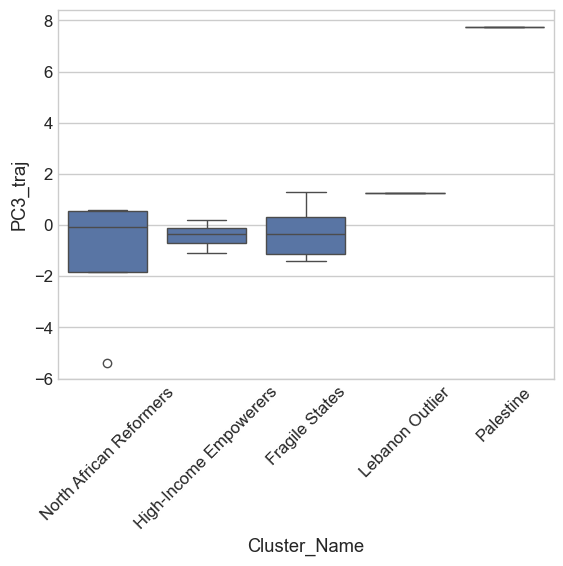

In [51]:
sns.boxplot(
    data=merged,
    x="Cluster_Name",
    y="PC3_traj"
)
plt.xticks(rotation=45)
plt.show()


## Trajectory Clustering

In [38]:
traj_pca_df.columns

Index(['PC1_traj', 'PC2_traj', 'PC3_traj', 'region'], dtype='object')

In [28]:

# Use first 3 PCs for clustering
traj_for_cluster = traj_pca_df[["PC1_traj", "PC2_traj", "PC3_traj"]].copy()

traj_for_cluster.head()


,PC1_traj,PC2_traj,PC3_traj
country_name,,,
Algeria,-2.009522,0.424644,-0.635280
Bahrain,3.900537,-0.513983,-0.772148
"Egypt, Arab Rep.",-3.473431,-1.642355,-1.407805
"Iran, Islamic Rep.",-3.100714,1.295938,0.349195
Iraq,-2.462522,-0.787292,-1.192613


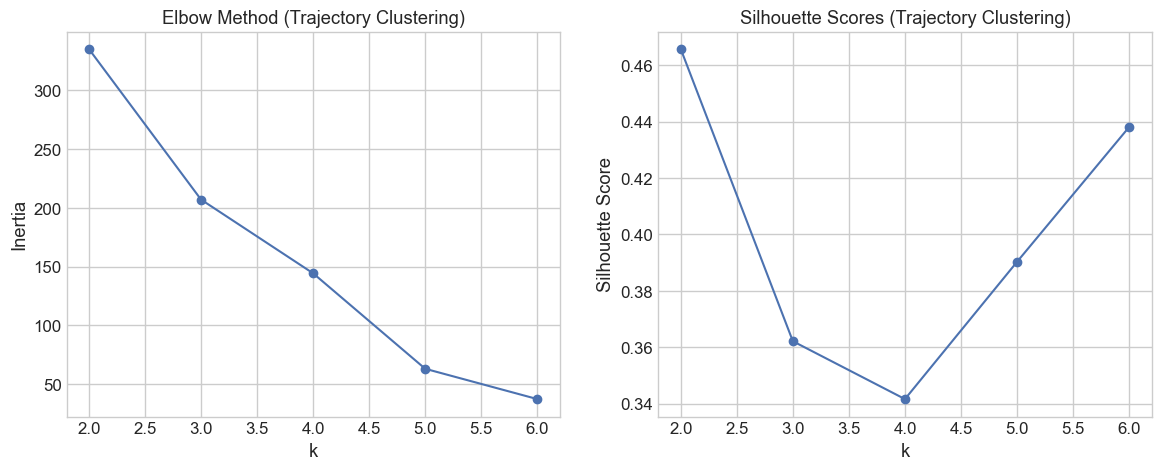

In [29]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K = range(2, 7)  # try between 2 and 6 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(traj_for_cluster)
    
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(traj_for_cluster, labels))

plt.figure(figsize=(14,5))

# Elbow
plt.subplot(1,2,1)
plt.plot(K, inertias, marker='o')
plt.title("Elbow Method (Trajectory Clustering)")
plt.xlabel("k")
plt.ylabel("Inertia")

# Silhouette
plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Scores (Trajectory Clustering)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.savefig(OUTPUT_DIR / "traj_clustering_elbow_silhouette.png", dpi=300)
plt.show()


In [30]:
k_opt = 6  # change this based on your silhouette plot!

kmeans_traj = KMeans(n_clusters=k_opt, random_state=42)
traj_labels = kmeans_traj.fit_predict(traj_for_cluster)

traj_pca_df["traj_cluster"] = traj_labels
traj_pca_df["traj_cluster"].value_counts().sort_index()


traj_cluster
0    4
1    9
2    1
3    1
4    1
5    2
Name: count, dtype: int64

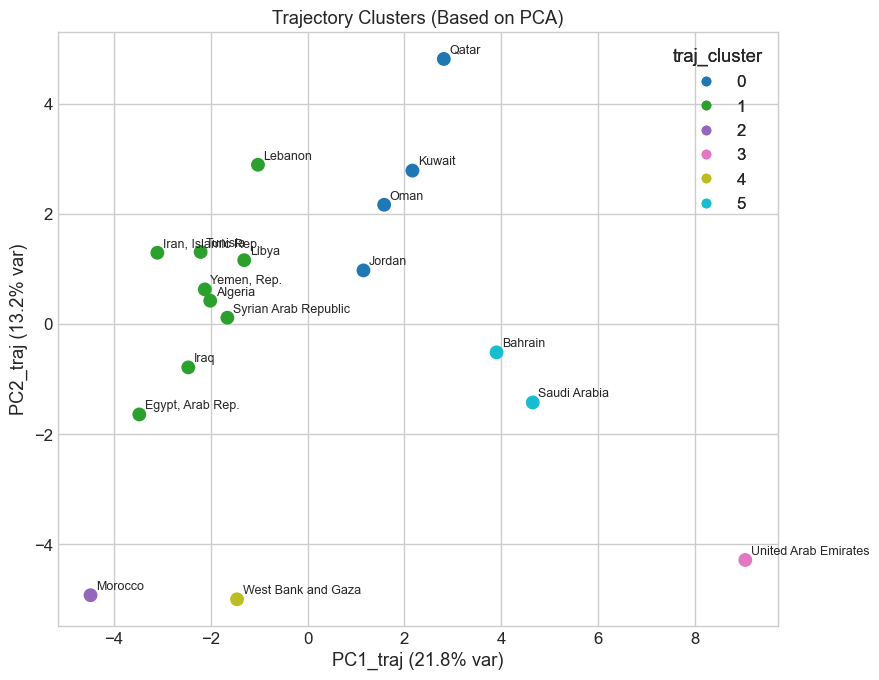

In [31]:
# ==== Cell 16: Scatter plot with trajectory cluster colours =================

fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    traj_pca_df["PC1_traj"],
    traj_pca_df["PC2_traj"],
    c=traj_pca_df["traj_cluster"],
    cmap="tab10",
    s=80
)

for country in traj_pca_df.index:
    x = traj_pca_df.loc[country, "PC1_traj"]
    y = traj_pca_df.loc[country, "PC2_traj"]
    ax.annotate(country, (x, y), fontsize=9, xytext=(4, 4), textcoords="offset points")

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="traj_cluster",
    loc="best"
)
ax.add_artist(legend1)

ax.set_xlabel(f"PC1_traj ({traj_var_ratio[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2_traj ({traj_var_ratio[1]*100:.1f}% var)")
ax.set_title("Trajectory Clusters (Based on PCA)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "traj_clusters_pca_space.png", dpi=300)
plt.show()



Cluster 0 → “Upward Movers” / “Accelerating Improvers”

Cluster 1 → “Stalled Trajectories” / “Slow or Negative Movers”

Cluster 2 → “Stable Decliners” or
“Long-Term Negative Trajectory”

Cluster 3 → “High-Performing Accelerators”
or
“Fast & Stable Improvers”

Cluster 4 → “Chronic Decline”
or
“Long-Term Downward Stability”

Cluster 5 → “Steady Reformers”
or
“Stable Positive Trajectories”



In [32]:
traj_cat_df = tr_df.join(traj_pca_df["traj_cluster"])
traj_cat_df["traj_cluster"] = traj_cat_df["traj_cluster"].astype(int)

traj_cat_df.head()


,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,cat_Economy_cagr,...,cat_WBL_dip,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation,traj_cluster
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.549136,-0.473852,-0.350839,-0.242434,0.224166,-0.921896,0.071014,-0.046670,1.132363,1.547746,...,-0.355247,-0.984961,-0.771285,-0.461836,-0.725564,-0.991195,-0.349694,-0.598305,-0.939696,1
Bahrain,-0.882325,0.760456,-0.350839,-0.242429,0.562547,0.385428,1.146376,1.179822,0.406997,-0.226594,...,-0.355247,0.315590,2.604167,-0.442636,0.572713,-0.173154,-0.351334,1.184993,0.728257,5
"Egypt, Arab Rep.",2.822389,-0.456292,-0.350839,-0.241799,0.044399,-0.718898,-0.703062,-0.089338,0.434902,-0.798706,...,0.683825,-0.993434,-0.580586,-0.463862,0.152224,-0.576052,-0.661778,-0.729994,0.182982,1
"Iran, Islamic Rep.",1.395218,-0.504950,-0.350839,-0.243086,0.503907,-0.839522,-0.809671,-0.769852,0.757223,1.852991,...,-0.355247,-0.928377,-0.483635,-0.458877,-1.242557,-0.515632,-1.168541,-0.805958,-1.086998,1
Iraq,1.071439,-0.258855,2.711630,-0.242974,-0.647004,0.500046,-0.216368,-0.066263,-0.401704,-0.740789,...,-0.355247,0.112563,1.039634,2.798915,-0.260512,-0.534701,-0.220204,-0.376614,0.152553,1


### Cluster × Feature Means (master summary table)

In [33]:
# 1. pick all category-level trajectory columns
traj_feature_cols = [
    c for c in traj_cat_df.columns
    if c.startswith("cat_") and c != "cat_dummy"  # adjust if you have any dummy
]

# 2. compute cluster means
cluster_feat_means = (
    traj_cat_df
    .groupby("traj_cluster")[traj_feature_cols]
    .mean()
    .sort_index()
)

cluster_feat_means.round(3)


,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,cat_Economy_cagr,...,cat_LegalAutonomy_dip,cat_WBL_dip,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation
traj_cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.615,0.743,-0.351,-0.243,0.590,0.548,-0.273,-0.487,0.305,0.302,...,-0.278,-0.199,1.023,-0.195,-0.455,0.744,1.056,0.882,0.490,0.614
1,0.422,-0.563,0.399,-0.243,0.050,-0.357,-0.452,-0.380,0.388,0.119,...,-0.206,-0.194,-0.553,-0.129,0.233,-0.310,-0.661,-0.564,-0.620,-0.645
2,-0.074,-0.541,-0.351,-0.242,-2.919,-2.098,-0.068,0.596,-0.714,-1.037,...,4.079,3.961,-1.293,-0.632,-0.427,-0.874,-0.126,-0.846,-0.643,-0.746
3,-0.287,0.781,-0.785,-0.241,0.217,1.129,2.793,2.247,-1.813,-0.818,...,-0.278,-0.355,1.623,-0.178,1.520,0.521,1.537,1.883,1.982,2.107
4,-0.775,-0.458,-0.351,4.123,-1.069,0.101,-0.810,-1.022,-1.120,-0.669,...,-0.278,-0.355,0.271,-0.166,-0.464,-1.595,0.390,0.010,-0.806,0.203
5,-0.102,1.158,-0.351,-0.242,0.479,0.947,1.621,1.776,-0.534,0.121,...,-0.278,-0.355,0.141,1.460,-0.451,0.880,-0.038,0.249,1.544,0.895


### Heatmaps: how clusters differ by metric & category

In [34]:

# map: metric → pretty label
metric_labels = {
    "trend_slope": "Trend Slope (Direction)",
    "rolling_std_5y": "5-year Volatility",
    "cagr": "CAGR (Average Growth)",
    "momentum": "Momentum (Recent vs Long-Term)",
    "spike": "Spike Count",
    "dip": "Dip Count",
}

def plot_metric_heatmap(metric, data=cluster_feat_means):
    # select columns ending with the metric name
    metric_cols = [c for c in data.columns if c.endswith(metric)]
    if not metric_cols:
        print(f"No columns found for metric '{metric}'")
        return
    
    # create cluster × category table
    tmp = data[metric_cols].copy()
    # column names become just the category (Demographics, Health, etc.)
    tmp.columns = [c.split("_")[1] for c in metric_cols]
    
    plt.figure(figsize=(10, 4))
    sns.heatmap(tmp, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"Trajectory Clusters – {metric_labels.get(metric, metric)}")
    plt.xlabel("Category")
    plt.ylabel("Trajectory Cluster")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"traj_cluster_heatmap_{metric}.png", dpi=300)
    plt.show()


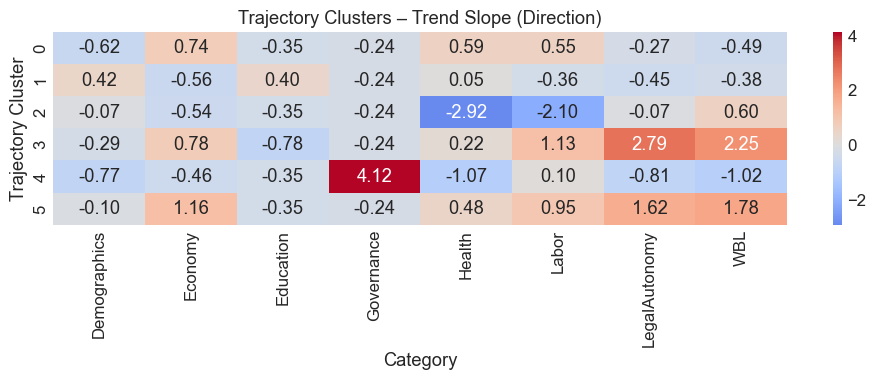

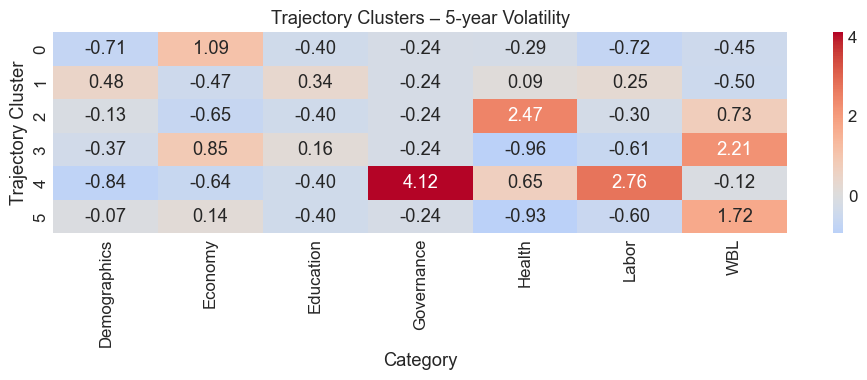

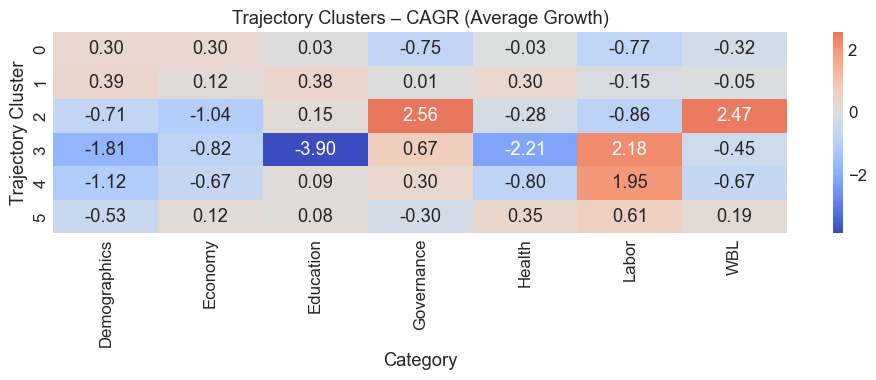

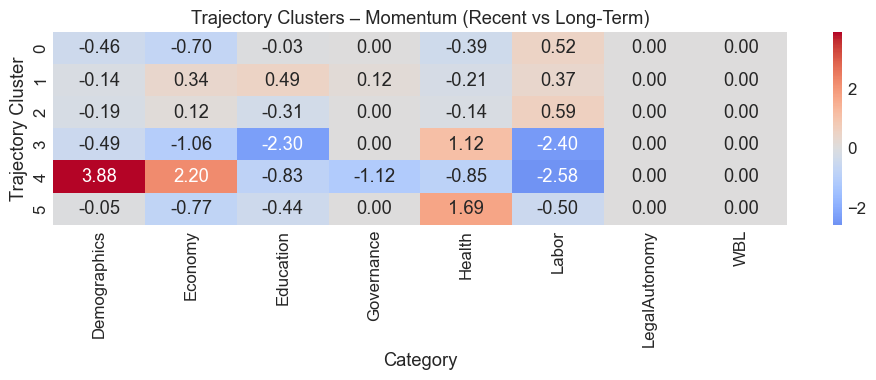

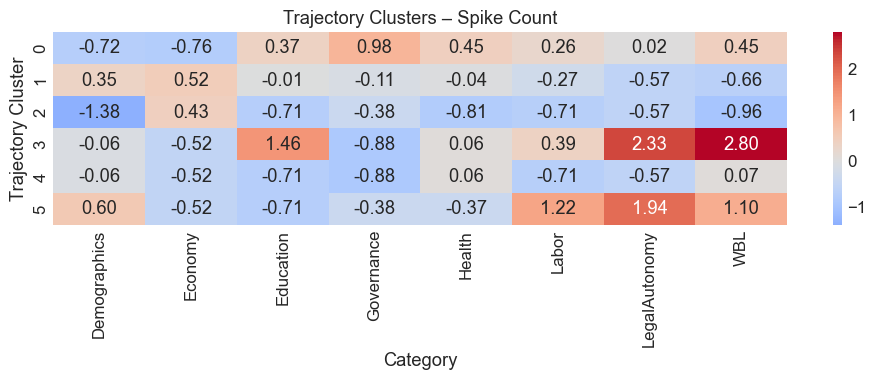

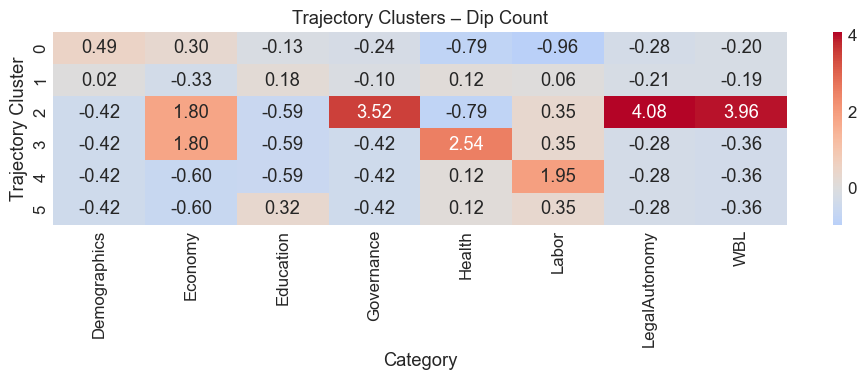

In [35]:
for m in ["trend_slope", "rolling_std_5y", "cagr", "momentum", "spike", "dip"]:
    plot_metric_heatmap(m)


### Cluster Names and Taglines

In [36]:
# ==== Cell 20: Cluster names + taglines =====================================

cluster_names = {
    0: "Steady Moderate Improvers",
    1: "Education-Led Social Improvers",
    2: "Morocco",
    3: "UAE",
    4: "Palestine",
    5: "Steady Reformers",
}

cluster_taglines = {
    0: "Slow, consistent upward movement across most categories.",
    1: "Social sectors (education, health) improving despite structural constraints.",
    2: "Chronic negative trajectory and long-term decline across dimensions.",
    3: "High-performing accelerator with strong, broad-based improvements.",
    4: "Stagnating under structural and political pressure.",
    5: "Balanced, stable reform path with moderate gains and controlled volatility.",
}

traj_cat_df["Cluster_Name"] = traj_cat_df["traj_cluster"].map(cluster_names)
traj_cat_df["Cluster_Tagline"] = traj_cat_df["traj_cluster"].map(cluster_taglines)

traj_cat_df.head()


,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,cat_Economy_cagr,...,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation,traj_cluster,Cluster_Name,Cluster_Tagline
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.549136,-0.473852,-0.350839,-0.242434,0.224166,-0.921896,0.071014,-0.046670,1.132363,1.547746,...,-0.771285,-0.461836,-0.725564,-0.991195,-0.349694,-0.598305,-0.939696,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
Bahrain,-0.882325,0.760456,-0.350839,-0.242429,0.562547,0.385428,1.146376,1.179822,0.406997,-0.226594,...,2.604167,-0.442636,0.572713,-0.173154,-0.351334,1.184993,0.728257,5,Steady Reformers,"Balanced, stable reform path with moderate gai..."
"Egypt, Arab Rep.",2.822389,-0.456292,-0.350839,-0.241799,0.044399,-0.718898,-0.703062,-0.089338,0.434902,-0.798706,...,-0.580586,-0.463862,0.152224,-0.576052,-0.661778,-0.729994,0.182982,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
"Iran, Islamic Rep.",1.395218,-0.504950,-0.350839,-0.243086,0.503907,-0.839522,-0.809671,-0.769852,0.757223,1.852991,...,-0.483635,-0.458877,-1.242557,-0.515632,-1.168541,-0.805958,-1.086998,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
Iraq,1.071439,-0.258855,2.711630,-0.242974,-0.647004,0.500046,-0.216368,-0.066263,-0.401704,-0.740789,...,1.039634,2.798915,-0.260512,-0.534701,-0.220204,-0.376614,0.152553,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."


### Radar charts: category profiles per cluster

In [37]:

traj_metrics_for_radar = ["trend_slope", "rolling_std_5y", "momentum", "cagr"]

# extract just those columns in the same order
radar_cols = [
    c for c in cluster_feat_means.columns
    if any(c.endswith(m) for m in traj_metrics_for_radar)
]

radar_df = cluster_feat_means[radar_cols].copy()

# z-score across clusters for each column
scaler_radar = StandardScaler()
radar_scaled = scaler_radar.fit_transform(radar_df)
radar_norm_df = pd.DataFrame(
    radar_scaled, index=radar_df.index, columns=radar_df.columns
)


In [38]:
def plot_cluster_radar(cluster_id, metric="trend_slope", cluster_names=None,metric_labels=None):
    # pick columns for one metric type
    cols = [c for c in radar_norm_df.columns if c.endswith(metric)]
    values = radar_norm_df.loc[cluster_id, cols].values
    labels = [c.split("_")[1] for c in cols]   # category names
    
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    values = np.concatenate([values, [values[0]]])
    angles = np.concatenate([angles, [angles[0]]])
    
    cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
    metric_name = metric_labels.get(metric, metric)
    title_text = f"{cluster_name} – {metric_name}"
    
    
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(title_text, fontsize=13, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"traj_cluster_{cluster_id}_radar_{metric}.png", dpi=300)
    plt.show()


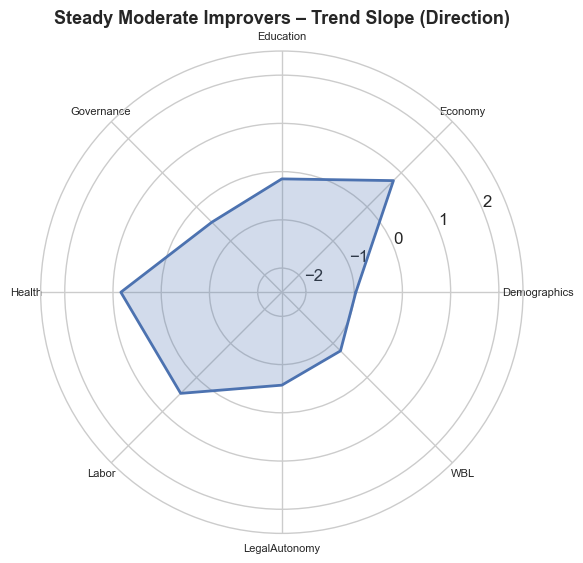

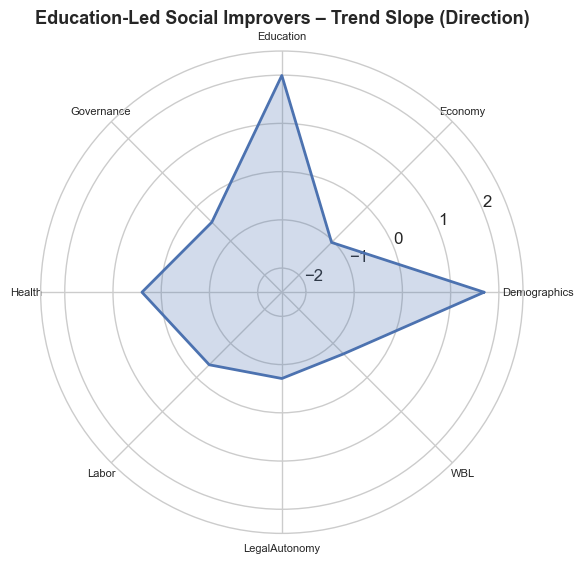

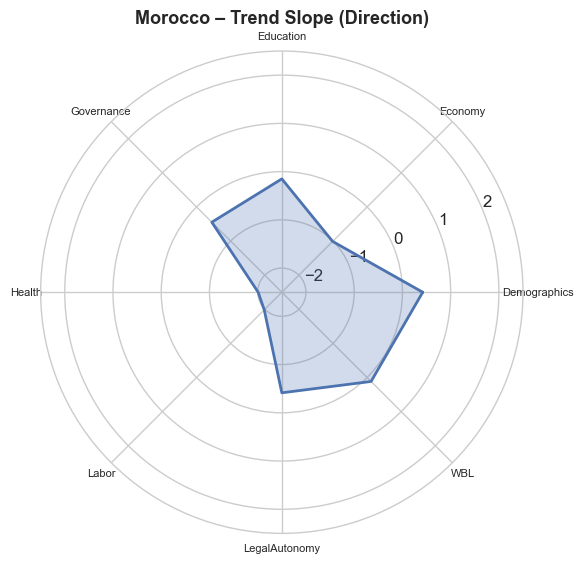

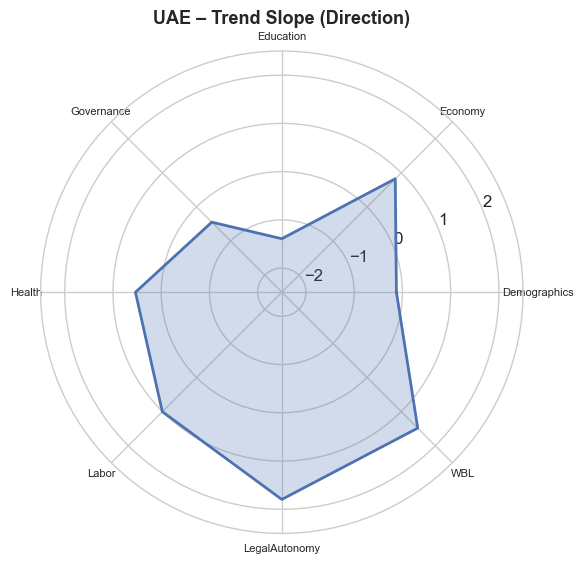

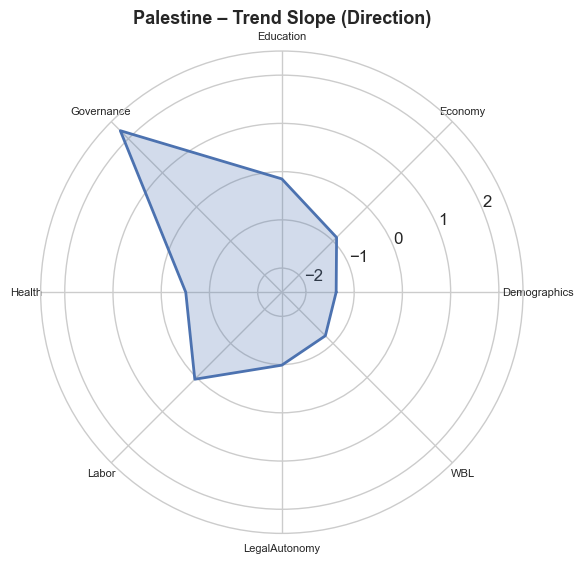

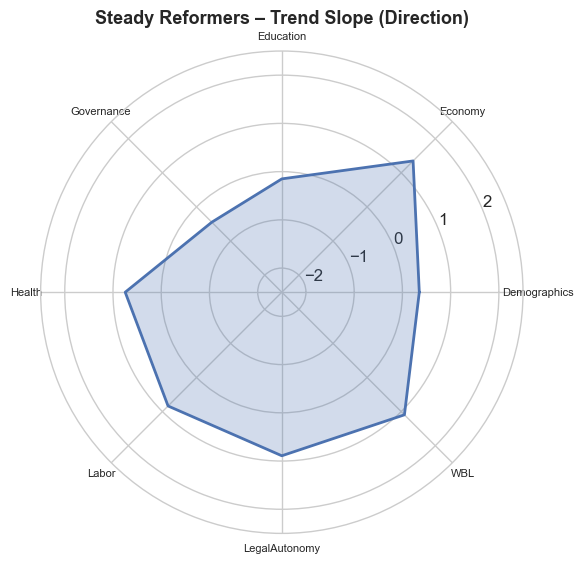

In [39]:
for cid in radar_norm_df.index:
    plot_cluster_radar(cid, metric="trend_slope",cluster_names=cluster_names,
        metric_labels=metric_labels)


### Spike & Dip sensitivity per cluster (barplots)

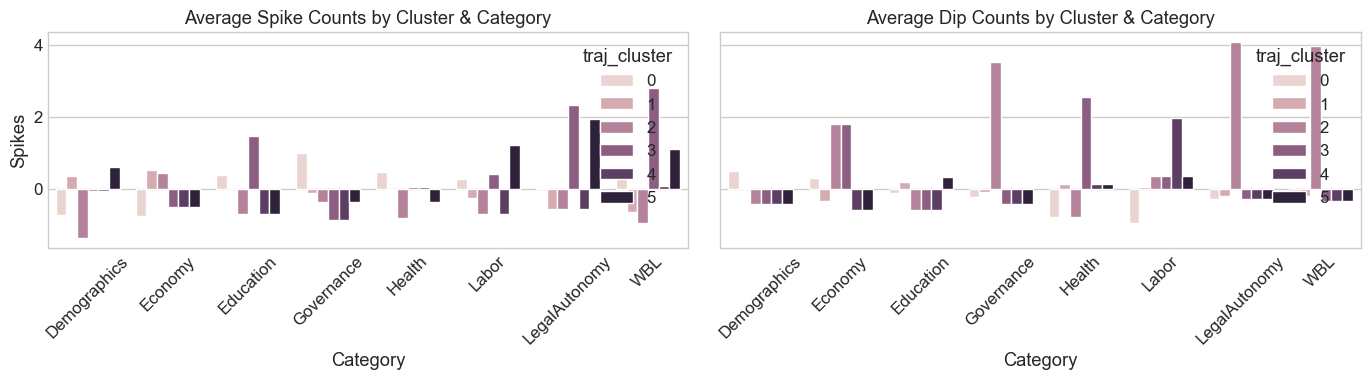

In [53]:
def plot_spike_dip_bars():
    # aggregate total spikes and dips per cluster & category
    spikes = [c for c in cluster_feat_means.columns if c.endswith("spike")]
    dips   = [c for c in cluster_feat_means.columns if c.endswith("dip")]
    
    spike_df = cluster_feat_means[spikes].copy()
    dip_df   = cluster_feat_means[dips].copy()
    
    spike_df.columns = [c.split("_")[1] for c in spikes]
    dip_df.columns   = [c.split("_")[1] for c in dips]
    
    # melt for seaborn
    spikes_long = spike_df.reset_index().melt(
        id_vars="traj_cluster", var_name="Category", value_name="Spikes"
    )
    dips_long = dip_df.reset_index().melt(
        id_vars="traj_cluster", var_name="Category", value_name="Dips"
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    sns.barplot(data=spikes_long, x="Category", y="Spikes",
                hue="traj_cluster", ax=axes[0])
    axes[0].set_title("Average Spike Counts by Cluster & Category")
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.barplot(data=dips_long, x="Category", y="Dips",
                hue="traj_cluster", ax=axes[1])
    axes[1].set_title("Average Dip Counts by Cluster & Category")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "traj_cluster_spike_dip_bars.png", dpi=300)
    plt.show()
    
plot_spike_dip_bars()


### Cluster-Level Narrative Generator

In [44]:
def cluster_narrative(cluster_id, cluster_data):
    name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")

    row = cluster_data.loc[cluster_id]

    # Identify top movements
    improving = row[[c for c in row.index if c.endswith("trend_slope")]].sort_values(ascending=False).head(2)
    declining = row[[c for c in row.index if c.endswith("trend_slope")]].sort_values().head(2)

    # Volatility
    vol = row[[c for c in row.index if c.endswith("rolling_std_5y")]].sort_values(ascending=False).head(1)

    # Momentum
    mom = row[[c for c in row.index if c.endswith("momentum")]].sort_values(ascending=False).head(1)

    # Spikes & dips
    spike = row[[c for c in row.index if c.endswith("spike")]].sort_values(ascending=False).head(1)
    dip = row[[c for c in row.index if c.endswith("dip")]].sort_values(ascending=False).head(1)

    narrative = f"""
# {name} – Cluster Narrative
Cluster ID: {cluster_id}

### **Overall Character**
This cluster exhibits a consistent pattern described as **"{name}"**, defined by its internal balance of long-term direction, volatility, and reform momentum.

### **Strongest Areas of Improvement**
The categories showing the strongest upward movement are:
- **{improving.index[0].split('_')[1]}**  
- **{improving.index[1].split('_')[1]}**

These areas drive the positive long-term trajectory of this cluster.

### **Key Areas of Decline or Stagnation**
Two categories show the weakest or negative trends:
- **{declining.index[0].split('_')[1]}**
- **{declining.index[1].split('_')[1]}**

These represent the main structural bottlenecks for countries in this group.

### **Volatility Profile**
The highest volatility is observed in:
- **{vol.index[0].split('_')[1]}**, indicating sensitivity to shocks, reforms, or instability.

### **Recent Momentum**
Momentum is strongest in:
- **{mom.index[0].split('_')[1]}**, suggesting that recent reforms or policy changes are accelerating progress.

### **Shock Sensitivity**
- Most frequent positive spikes: **{spike.index[0].split('_')[1]}**
- Most frequent negative dips: **{dip.index[0].split('_')[1]}**

This reveals which categories are most affected by events such as crises, reforms, or conflicts.

### **Interpretation**
Taken together, this cluster represents:
- its reform orientation,
- structural vulnerabilities,
- categories that respond to shocks,
- and where policy interventions would be most impactful.

"""

    return narrative


In [45]:
cluster_narratives = {}

for cid in cluster_feat_means.index:
    cluster_narratives[cid] = cluster_narrative(cid, cluster_feat_means)
    print(cluster_narratives[cid])


# Steady Moderate Improvers – Cluster Narrative
Cluster ID: 0

### **Overall Character**
This cluster exhibits a consistent pattern described as **"Steady Moderate Improvers"**, defined by its internal balance of long-term direction, volatility, and reform momentum.

### **Strongest Areas of Improvement**
The categories showing the strongest upward movement are:
- **Economy**  
- **Health**

These areas drive the positive long-term trajectory of this cluster.

### **Key Areas of Decline or Stagnation**
Two categories show the weakest or negative trends:
- **Demographics**
- **WBL**

These represent the main structural bottlenecks for countries in this group.

### **Volatility Profile**
The highest volatility is observed in:
- **Economy**, indicating sensitivity to shocks, reforms, or instability.

### **Recent Momentum**
Momentum is strongest in:
- **Labor**, suggesting that recent reforms or policy changes are accelerating progress.

### **Shock Sensitivity**
- Most frequent positive

### Country-Level Narrative Generator

In [41]:
def country_narrative(country, traj_cat_df, cluster_feat_means):
    row = traj_cat_df.loc[country]
    cid = row["traj_cluster"]
    cname = cluster_names.get(cid, f"Cluster {cid}")

    cluster_avg = cluster_feat_means.loc[cid]

    diffs = row[cluster_feat_means.columns] - cluster_avg

    strongest = diffs.sort_values(ascending=False).head(2)
    weakest = diffs.sort_values().head(2)

    narrative = f"""
# {country}: Trajectory Narrative
Cluster: **{cname}**

### **Overall Position**
{country} belongs to the trajectory cluster **"{cname}"**, sharing a common developmental path with similar MENA countries in terms of long-term direction, reform momentum, and volatility.

### **Areas Where {country} Outperforms Its Cluster**
The country exceeds the average cluster performance in:
- **{strongest.index[0].split('_')[1]}**
- **{strongest.index[1].split('_')[1]}**

This indicates relative strength and resilience in these dimensions.

### **Areas Where {country} Underperforms**
The largest weaknesses compared to its cluster peers occur in:
- **{weakest.index[0].split('_')[1]}**
- **{weakest.index[1].split('_')[1]}**

These areas represent structural constraints or reform gaps.

### **Strategic Interpretation**
The country’s trajectory suggests:
- categories where reform is already producing measurable impact,
- categories that require corrective policy intervention,
- its deviation from the cluster’s dominant narrative.

"""

    return narrative


In [46]:
country_narratives = {}

for country in traj_cat_df.index:
    country_narratives[country] = country_narrative(country, traj_cat_df, cluster_feat_means)
    print(country_narratives[country])


# Algeria: Trajectory Narrative
Cluster: **Education-Led Social Improvers**

### **Overall Position**
Algeria belongs to the trajectory cluster **"Education-Led Social Improvers"**, sharing a common developmental path with similar MENA countries in terms of long-term direction, reform momentum, and volatility.

### **Areas Where Algeria Outperforms Its Cluster**
The country exceeds the average cluster performance in:
- **Labor**
- **Economy**

This indicates relative strength and resilience in these dimensions.

### **Areas Where Algeria Underperforms**
The largest weaknesses compared to its cluster peers occur in:
- **Education**
- **Labor**

These areas represent structural constraints or reform gaps.

### **Strategic Interpretation**
The country’s trajectory suggests:
- categories where reform is already producing measurable impact,
- categories that require corrective policy intervention,
- its deviation from the cluster’s dominant narrative.



# Bahrain: Trajectory Narrative
Clu

### Comparison Generator Between Structural Clusters (Part 1) and Trajectory Clusters (Part 2)

In [52]:
# Standardize indexes for both models
structural_cluster_df = structural_cluster_df.copy()
traj_cat_df = traj_cat_df.copy()

# Ensure both use country_name as index
if "country_name" in structural_cluster_df.columns:
    structural_cluster_df = structural_cluster_df.set_index("country_name")

if "country_name" in traj_cat_df.columns:
    traj_cat_df = traj_cat_df.set_index("country_name")

# Strip spaces
structural_cluster_df.index = structural_cluster_df.index.str.strip()
traj_cat_df.index = traj_cat_df.index.str.strip()

# Make sure all countries align
print("Countries in Part 1 but not Part 2:", 
      set(structural_cluster_df.index) - set(traj_cat_df.index))

print("Countries in Part 2 but not Part 1:", 
      set(traj_cat_df.index) - set(structural_cluster_df.index))


Countries in Part 1 but not Part 2: set()
Countries in Part 2 but not Part 1: set()


In [53]:
def compare_models(country, part1_df, part2_df):
    if country not in part1_df.index:
        return f"{country}: Not found in structural clustering model."

    if country not in part2_df.index:
        return f"{country}: Not found in trajectory clustering model."

    scluster = part1_df.loc[country, "Cluster_Name"]
    tcluster = part2_df.loc[country, "Cluster_Name"]

    narrative = f"""
# {country} – Cross-Model Comparison

### 🧱 Structural Cluster (Part 1)
{scluster}

### 🔄 Trajectory Cluster (Part 2)
{tcluster}

### 🔍 Interpretation
Structural clusters reflect **baseline conditions** (levels, stability, socioeconomic context).
Trajectory clusters reflect **movement** (direction, growth, volatility).

Together, they show:
- whether structural strengths translate into progress,
- whether reforms align with capacity,
- whether shocks divert a country from its structural path,
- and which countries are *overperforming* or *underperforming* relative to their baseline.

"""

    return narrative


In [54]:
comparison_narratives = {}

for country in traj_cat_df.index:
    comparison_narratives[country] = compare_models(country, structural_cluster_df, traj_cat_df)
    print(comparison_narratives[country])


# Algeria – Cross-Model Comparison

### 🧱 Structural Cluster (Part 1)
North African Reformers

### 🔄 Trajectory Cluster (Part 2)
Education-Led Social Improvers

### 🔍 Interpretation
Structural clusters reflect **baseline conditions** (levels, stability, socioeconomic context).
Trajectory clusters reflect **movement** (direction, growth, volatility).

Together, they show:
- whether structural strengths translate into progress,
- whether reforms align with capacity,
- whether shocks divert a country from its structural path,
- and which countries are *overperforming* or *underperforming* relative to their baseline.



# Bahrain – Cross-Model Comparison

### 🧱 Structural Cluster (Part 1)
High-Income Empowerers

### 🔄 Trajectory Cluster (Part 2)
Steady Reformers

### 🔍 Interpretation
Structural clusters reflect **baseline conditions** (levels, stability, socioeconomic context).
Trajectory clusters reflect **movement** (direction, growth, volatility).

Together, they show:
- whether struct

In [55]:
traj_cat_df.columns

Index(['cat_Demographics_trend_slope', 'cat_Economy_trend_slope',
       'cat_Education_trend_slope', 'cat_Governance_trend_slope',
       'cat_Health_trend_slope', 'cat_Labor_trend_slope',
       'cat_LegalAutonomy_trend_slope', 'cat_WBL_trend_slope',
       'cat_Demographics_cagr', 'cat_Economy_cagr', 'cat_Education_cagr',
       'cat_Governance_cagr', 'cat_Health_cagr', 'cat_Labor_cagr',
       'cat_WBL_cagr', 'cat_Demographics_momentum', 'cat_Economy_momentum',
       'cat_Education_momentum', 'cat_Governance_momentum',
       'cat_Health_momentum', 'cat_Labor_momentum',
       'cat_LegalAutonomy_momentum', 'cat_WBL_momentum',
       'cat_Demographics_rolling_std_5y', 'cat_Economy_rolling_std_5y',
       'cat_Education_rolling_std_5y', 'cat_Governance_rolling_std_5y',
       'cat_Health_rolling_std_5y', 'cat_Labor_rolling_std_5y',
       'cat_WBL_rolling_std_5y', 'cat_Demographics_spike', 'cat_Economy_spike',
       'cat_Education_spike', 'cat_Governance_spike', 'cat_Health_spike',

In [34]:
cluster_names = {
    0: "Steady Moderate Improvers",
    1: "Education-Led Social Improvers",
    2: "Morocco",
    3: "UAE",
    4: "Palestine",
    5: "Steady Reformers"
}

traj_cat_df['Cluster_Name'] = traj_cat_df['traj_cluster'].map(cluster_names)

In [35]:
traj_cat_df.head(10)

,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,cat_Economy_cagr,...,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation,traj_cluster,Cluster_Name
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.549136,-0.473852,-0.350839,-0.242434,0.224166,-0.921896,0.071014,-0.046670,1.132363,1.547746,...,-0.984961,-0.771285,-0.461836,-0.725564,-0.991195,-0.349694,-0.598305,-0.939696,1,Education-Led Social Improvers
Bahrain,-0.882325,0.760456,-0.350839,-0.242429,0.562547,0.385428,1.146376,1.179822,0.406997,-0.226594,...,0.315590,2.604167,-0.442636,0.572713,-0.173154,-0.351334,1.184993,0.728257,5,Steady Reformers
"Egypt, Arab Rep.",2.822389,-0.456292,-0.350839,-0.241799,0.044399,-0.718898,-0.703062,-0.089338,0.434902,-0.798706,...,-0.993434,-0.580586,-0.463862,0.152224,-0.576052,-0.661778,-0.729994,0.182982,1,Education-Led Social Improvers
"Iran, Islamic Rep.",1.395218,-0.504950,-0.350839,-0.243086,0.503907,-0.839522,-0.809671,-0.769852,0.757223,1.852991,...,-0.928377,-0.483635,-0.458877,-1.242557,-0.515632,-1.168541,-0.805958,-1.086998,1,Education-Led Social Improvers
Iraq,1.071439,-0.258855,2.711630,-0.242974,-0.647004,0.500046,-0.216368,-0.066263,-0.401704,-0.740789,...,0.112563,1.039634,2.798915,-0.260512,-0.534701,-0.220204,-0.376614,0.152553,1,Education-Led Social Improvers
Jordan,-0.333100,-0.440858,-0.350839,-0.242625,0.158127,0.392162,0.108095,0.434435,0.775221,-0.043294,...,-0.051454,-0.294499,-0.474617,2.035369,-0.520959,-0.880680,1.531161,1.736010,0,Steady Moderate Improvers
Kuwait,-0.687887,-0.034478,-0.350839,-0.242654,0.805370,0.636329,-0.160746,-0.572185,1.053478,-0.554891,...,1.088889,-1.093709,-0.458887,1.240059,2.932346,1.860175,-0.549375,0.222080,0,Steady Moderate Improvers
Lebanon,-0.807673,-0.530292,0.104519,-0.242910,0.840208,-0.146975,-0.809671,-0.711510,-0.360043,1.444054,...,-0.303498,2.032109,-0.357578,1.084739,-0.300666,-0.706938,-0.805958,-1.125756,1,Education-Led Social Improvers
Libya,-0.811263,-0.690818,2.880438,-0.242362,0.788483,0.754378,-0.160746,-0.123734,1.459493,-1.952068,...,-0.985390,-0.561166,2.228251,-0.084665,-0.806577,-1.267441,-0.634903,-0.630142,1,Education-Led Social Improvers


In [57]:
traj_cat_df.to_csv("data/2_df_traj_clusters.csv", index=True)


In [58]:
traj_cat_df.head()

,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,cat_Economy_cagr,...,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation,traj_cluster,Cluster_Name,Cluster_Tagline
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.549136,-0.473852,-0.350839,-0.242434,0.224166,-0.921896,0.071014,-0.046670,1.132363,1.547746,...,-0.771285,-0.461836,-0.725564,-0.991195,-0.349694,-0.598305,-0.939696,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
Bahrain,-0.882325,0.760456,-0.350839,-0.242429,0.562547,0.385428,1.146376,1.179822,0.406997,-0.226594,...,2.604167,-0.442636,0.572713,-0.173154,-0.351334,1.184993,0.728257,5,Steady Reformers,"Balanced, stable reform path with moderate gai..."
"Egypt, Arab Rep.",2.822389,-0.456292,-0.350839,-0.241799,0.044399,-0.718898,-0.703062,-0.089338,0.434902,-0.798706,...,-0.580586,-0.463862,0.152224,-0.576052,-0.661778,-0.729994,0.182982,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
"Iran, Islamic Rep.",1.395218,-0.504950,-0.350839,-0.243086,0.503907,-0.839522,-0.809671,-0.769852,0.757223,1.852991,...,-0.483635,-0.458877,-1.242557,-0.515632,-1.168541,-0.805958,-1.086998,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
Iraq,1.071439,-0.258855,2.711630,-0.242974,-0.647004,0.500046,-0.216368,-0.066263,-0.401704,-0.740789,...,1.039634,2.798915,-0.260512,-0.534701,-0.220204,-0.376614,0.152553,1,Education-Led Social Improvers,"Social sectors (education, health) improving d..."
